In [1]:
import pandas as pd

df = pd.read_csv(
    "data/bank-additional-full.csv",
    sep=";"
)

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
df.shape

(41188, 21)

In [4]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [7]:
for col in df.select_dtypes(include="str").columns:
    print(col, df[col].value_counts().to_dict())

job {'admin.': 10422, 'blue-collar': 9254, 'technician': 6743, 'services': 3969, 'management': 2924, 'retired': 1720, 'entrepreneur': 1456, 'self-employed': 1421, 'housemaid': 1060, 'unemployed': 1014, 'student': 875, 'unknown': 330}
marital {'married': 24928, 'single': 11568, 'divorced': 4612, 'unknown': 80}
education {'university.degree': 12168, 'high.school': 9515, 'basic.9y': 6045, 'professional.course': 5243, 'basic.4y': 4176, 'basic.6y': 2292, 'unknown': 1731, 'illiterate': 18}
default {'no': 32588, 'unknown': 8597, 'yes': 3}
housing {'yes': 21576, 'no': 18622, 'unknown': 990}
loan {'no': 33950, 'yes': 6248, 'unknown': 990}
contact {'cellular': 26144, 'telephone': 15044}
month {'may': 13769, 'jul': 7174, 'aug': 6178, 'jun': 5318, 'nov': 4101, 'apr': 2632, 'oct': 718, 'sep': 570, 'mar': 546, 'dec': 182}
day_of_week {'thu': 8623, 'mon': 8514, 'wed': 8134, 'tue': 8090, 'fri': 7827}
poutcome {'nonexistent': 35563, 'failure': 4252, 'success': 1373}
y {'no': 36548, 'yes': 4640}


In [8]:
df["y"].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [9]:
baseline_accuracy = df["y"].value_counts(normalize=True).max()
baseline_accuracy

np.float64(0.8873458288821987)

In [2]:
df["target"] = df["y"].map({
    "no": 0,
    "yes": 1
})

df[["y", "target"]].head()


,y,target
0,no,0
1,no,0
2,no,0
3,no,0
4,no,0


In [3]:
X = df.drop(columns=["y", "target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41188, 20)
y shape: (41188,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (28831, 20) (28831,)
Validation: (6178, 20) (6178,)
Test: (6179, 20) (6179,)


In [5]:
print("Train positive rate:", y_train.mean())
print("Validation positive rate:", y_val.mean())
print("Test positive rate:", y_test.mean())

Train positive rate: 0.11265651555617218
Validation positive rate: 0.11265781806409841
Test positive rate: 0.11263958569347791


In [6]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="str"
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [9]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [10]:
y_val_pred = logistic_model.predict(X_val)

y_val_pred[:20]

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [11]:
from sklearn.metrics import accuracy_score

val_accuracy = accuracy_score(
    y_val,
    y_val_pred
)

val_accuracy

0.9138879896406604

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val,
    y_val_pred
)

cm

array([[5353,  129],
       [ 403,  293]])

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.6943127962085308
Recall: 0.4209770114942529
F1: 0.5241502683363148


In [15]:
y_val_prob = logistic_model.predict_proba(X_val)[:, 1]

y_val_prob[:20]


array([0.0098381 , 0.03687193, 0.87963744, 0.0083296 , 0.0418042 ,
       0.0832594 , 0.01617676, 0.01062027, 0.01525633, 0.01676738,
       0.02500161, 0.02781459, 0.00997169, 0.2379917 , 0.02503878,
       0.85254483, 0.03071125, 0.02974031, 0.02798653, 0.0117878 ])

In [16]:
threshold = 0.3

y_val_pred_03 = (
    y_val_prob >= threshold
).astype(int)

print(
    confusion_matrix(
        y_val,
        y_val_pred_03
    )
)

print(
    "Precision:",
    precision_score(
        y_val,
        y_val_pred_03
    )
)

print(
    "Recall:",
    recall_score(
        y_val,
        y_val_pred_03
    )
)

print(
    "F1:",
    f1_score(
        y_val,
        y_val_pred_03
    )
)

[[5195  287]
 [ 264  432]]
Precision: 0.6008344923504868
Recall: 0.6206896551724138
F1: 0.610600706713781


In [17]:
import pandas as pd

threshold_results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    predictions = (
        y_val_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val,
            predictions
        ),
        "recall": recall_score(
            y_val,
            predictions
        ),
        "f1": f1_score(
            y_val,
            predictions
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df


,threshold,precision,recall,f1
0,0.1,0.425303,0.908046,0.579285
1,0.2,0.528942,0.761494,0.624264
2,0.3,0.600834,0.620690,0.610601
3,0.4,0.640074,0.495690,0.558704
4,0.5,0.694313,0.420977,0.524150
5,0.6,0.708861,0.321839,0.442688
6,0.7,0.733906,0.245690,0.368138


In [18]:
import numpy as np
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

f1_scores = (
    2 * precisions[:-1] * recalls[:-1]
    / (precisions[:-1] + recalls[:-1] + 1e-12)
)

best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]
best_precision = precisions[best_index]
best_recall = recalls[best_index]
best_f1 = f1_scores[best_index]

print("Best threshold:", best_threshold)
print("Best precision:", best_precision)
print("Best recall:", best_recall)
print("Best F1:", best_f1)

Best threshold: 0.21557147109207142
Best precision: 0.5431841831425598
Best recall: 0.75
Best F1: 0.6300543150266701


In [19]:
y_val_pred_best = (
    y_val_prob >= best_threshold
).astype(int)

confusion_matrix(
    y_val,
    y_val_pred_best
)

array([[5043,  439],
       [ 174,  522]])

In [20]:
comparison = pd.DataFrame({
    "metric": ["Precision", "Recall", "F1"],
    "threshold_0.5": [
        precision_score(y_val, y_val_pred),
        recall_score(y_val, y_val_pred),
        f1_score(y_val, y_val_pred)
    ],
    "best_threshold": [
        precision_score(y_val, y_val_pred_best),
        recall_score(y_val, y_val_pred_best),
        f1_score(y_val, y_val_pred_best)
    ]
})

comparison

,metric,threshold_0.5,best_threshold
0,Precision,0.694313,0.543184
1,Recall,0.420977,0.750000
2,F1,0.524150,0.630054


In [21]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc = average_precision_score(
    y_val,
    y_val_prob
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9387056175487594
PR-AUC: 0.6276298870288938


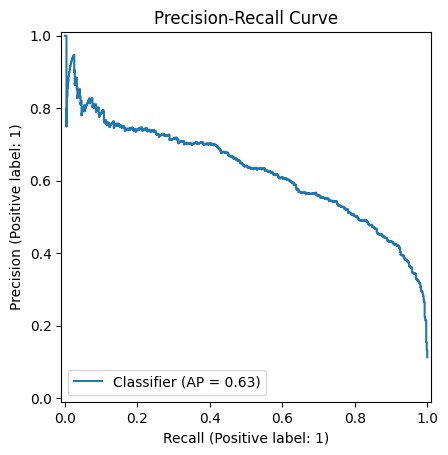

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_val,
    y_val_prob
)

plt.title("Precision-Recall Curve")
plt.show()

In [27]:
X_train_nd = X_train.drop(columns=["duration"])
X_val_nd = X_val.drop(columns=["duration"])
X_test_nd = X_test.drop(columns=["duration"])

In [28]:
numeric_features_nd = X_train_nd.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_nd = X_train_nd.select_dtypes(
    include="str"
).columns.tolist()

print("Numeric features without duration:")
print(numeric_features_nd)

print("\nCategorical features:")
print(categorical_features_nd)

Numeric features without duration:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [29]:
preprocessor_nd = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features_nd
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_nd
        )
    ]
)

preprocessor_nd

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

In [30]:
logistic_model_nd = Pipeline(
    steps=[
        ("preprocessor", preprocessor_nd),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model_nd.fit(
    X_train_nd,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [31]:
y_val_prob_nd = logistic_model_nd.predict_proba(
    X_val_nd
)[:, 1]

y_val_prob_nd[:20]

array([0.04624539, 0.06942053, 0.04293895, 0.04719964, 0.10957867,
       0.13334475, 0.05013543, 0.04095024, 0.05983558, 0.04890982,
       0.07394606, 0.10273151, 0.03380417, 0.24339943, 0.09320899,
       0.69454508, 0.05725605, 0.03407767, 0.04798938, 0.06785683])

In [32]:
roc_auc_nd = roc_auc_score(
    y_val,
    y_val_prob_nd
)

pr_auc_nd = average_precision_score(
    y_val,
    y_val_prob_nd
)

print("With duration:")
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

print("\nWithout duration:")
print("ROC-AUC:", roc_auc_nd)
print("PR-AUC:", pr_auc_nd)

With duration:
ROC-AUC: 0.9387056175487594
PR-AUC: 0.6276298870288938

Without duration:
ROC-AUC: 0.8021599948839883
PR-AUC: 0.4700697725957582


In [33]:
precisions_nd, recalls_nd, thresholds_nd = precision_recall_curve(
    y_val,
    y_val_prob_nd
)

f1_scores_nd = (
    2 * precisions_nd[:-1] * recalls_nd[:-1]
    / (
        precisions_nd[:-1]
        + recalls_nd[:-1]
        + 1e-12
    )
)

best_index_nd = np.argmax(f1_scores_nd)

best_threshold_nd = thresholds_nd[best_index_nd]
best_precision_nd = precisions_nd[best_index_nd]
best_recall_nd = recalls_nd[best_index_nd]
best_f1_nd = f1_scores_nd[best_index_nd]

print("Best threshold:", best_threshold_nd)
print("Best precision:", best_precision_nd)
print("Best recall:", best_recall_nd)
print("Best F1:", best_f1_nd)

Best threshold: 0.2207722905250567
Best precision: 0.46365914786967416
Best recall: 0.5316091954022989
Best F1: 0.4953145916996362


In [35]:
y_val_pred_best_nd = (
    y_val_prob_nd >= best_threshold_nd
).astype(int)

confusion_matrix(
    y_val,
    y_val_pred_best_nd
)

array([[5054,  428],
       [ 326,  370]])

In [36]:
model_comparison = pd.DataFrame({
    "model": [
        "Logistic Regression with duration",
        "Logistic Regression without duration"
    ],
    "ROC_AUC": [
        roc_auc,
        roc_auc_nd
    ],
    "PR_AUC": [
        pr_auc,
        pr_auc_nd
    ],
    "best_threshold": [
        best_threshold,
        best_threshold_nd
    ],
    "precision": [
        best_precision,
        best_precision_nd
    ],
    "recall": [
        best_recall,
        best_recall_nd
    ],
    "F1": [
        best_f1,
        best_f1_nd
    ]
})

model_comparison

,model,ROC_AUC,PR_AUC,best_threshold,precision,recall,F1
0,Logistic Regression with duration,0.938706,0.62763,0.215571,0.543184,0.750000,0.630054
1,Logistic Regression without duration,0.802160,0.47007,0.220772,0.463659,0.531609,0.495315
